In [ ]:
!pip -q install folium branca  # remova esta linha se já tiver folium no ambiente

HTML salvo em: /content/figuras_cap6/mapa_5bases_interativo.html


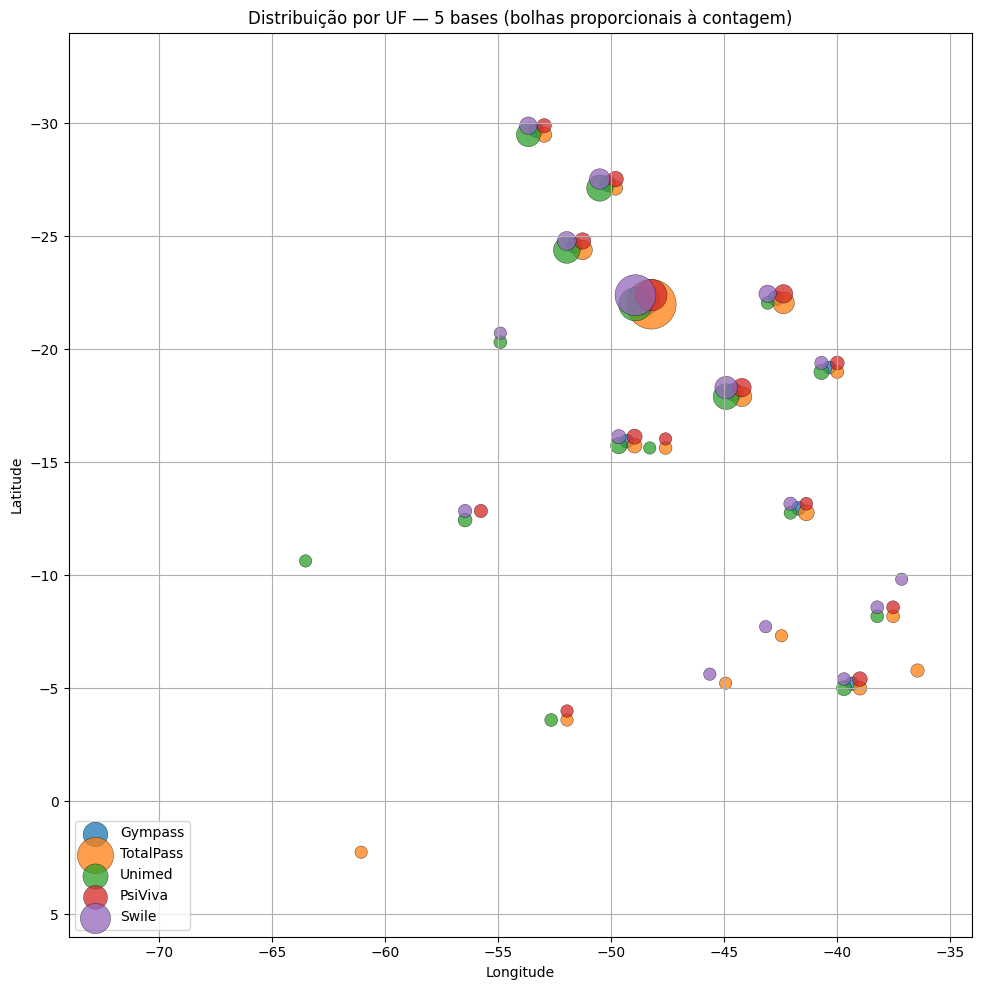

PNG salvo em: /content/figuras_cap6/mapa_5bases_estatico.png


In [ ]:
# ================================================
# Mapa do Brasil por UF: 5 bases juntas
# - HTML interativo: folium (bolhas coloridas por base)
# - PNG estático: matplotlib (fallback)
# ================================================

import folium
from folium import FeatureGroup
from branca.element import MacroElement
from jinja2 import Template
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- DADOS (como você enviou) ----------
gympass = {
    "SP":72,"MG":14,"SC":9,"PR":8,"RJ":7,"RS":6,"BA":4,"GO":4,"CE":3,"ES":2
}
totalpass = {
    "SP":184,"RJ":26,"MG":20,"PR":19,"BA":9,"RS":7,"GO":6,"SC":5,"CE":4,"RN":3,"PE":2,"DF":2,"ES":2,"PA":1,"RR":1,"MA":1,"PI":1
}
unimed = {
    "SP":77,"PR":45,"SC":43,"MG":41,"RS":34,"GO":10,"CE":7,"ES":7,"MT":4,"MS":2,"RJ":2,"PE":2,"BA":2,"PA":2,"DF":1,"RO":1
}
psiviva = {
    "SP":67,"MG":16,"RJ":16,"PR":10,"SC":8,"GO":7,"CE":6,"RS":5,"ES":4,"MT":3,"BA":2,"PE":2,"DF":1,"PA":1
}
swile = {
    "SP":121,"MG":29,"SC":22,"PR":17,"RJ":13,"RS":13,"GO":5,"BA":3,"ES":3,"MT":3,"PE":2,"CE":2,"MS":1,"MA":1,"PI":1,"AL":1
}

datasets = {
    "Gympass": gympass,
    "TotalPass": totalpass,
    "Unimed": unimed,
    "PsiViva": psiviva,
    "Swile": swile
}

# ---------- Centroides aproximados por UF (lon, lat) ----------
UF_CENTROIDE = {
    "AC": (-70.55, -9.02), "AL": (-36.78, -9.62), "AP": (-51.77, 1.41), "AM": (-63.90, -3.47),
    "BA": (-41.70, -12.96), "CE": (-39.33, -5.20), "DF": (-47.93, -15.83), "ES": (-40.33, -19.19),
    "GO": (-49.30, -15.93), "MA": (-45.27, -5.42), "MT": (-56.10, -12.64), "MS": (-54.54, -20.51),
    "MG": (-44.55, -18.10), "PA": (-52.29, -3.79), "PB": (-36.72, -7.24), "PR": (-51.60, -24.59),
    "PE": (-37.86, -8.38),  "PI": (-42.80, -7.52), "RJ": (-42.71, -22.25), "RN": (-36.78, -5.98),
    "RO": (-63.16, -10.83), "RR": (-61.40, 2.06),  "RS": (-53.30, -29.69), "SC": (-50.14, -27.33),
    "SE": (-37.44, -10.57), "SP": (-48.56, -22.19), "TO": (-48.26, -10.18)
}

# ---------- Aparência ----------
COLORS = {
    "Gympass": "#1f77b4",    # azul
    "TotalPass": "#ff7f0e",  # laranja
    "Unimed": "#2ca02c",     # verde
    "PsiViva": "#d62728",    # vermelho
    "Swile": "#9467bd"       # roxo
}
# Pequenos deslocamentos para reduzir sobreposição (lon, lat)
OFFSETS = {
    "Gympass": (0.00, 0.00),
    "TotalPass": (0.35, 0.20),
    "Unimed": (-0.35, 0.20),
    "PsiViva": (0.35, -0.20),
    "Swile": (-0.35, -0.20)
}

# ---------- Escala de raio (compartilhada entre todas as bases) ----------
all_counts = np.array([v for d in datasets.values() for v in d.values()], dtype=float)
cmin, cmax = all_counts.min(), all_counts.max()

def scale_radius(count, rmin=4, rmax=22):
    # mapeia contagem para raio em pixels de forma linear
    return rmin + (rmax - rmin) * (count - cmin) / (cmax - cmin + 1e-9)

# =================================================
# (A) HTML DINÂMICO — FOLIUM
# =================================================
m = folium.Map(location=[-15.78, -52.0], zoom_start=4, tiles="CartoDB positron", control_scale=True)

# cria um grupo de camadas por base
for base, data in datasets.items():
    fg = FeatureGroup(name=base, show=True)
    color = COLORS[base]
    dx, dy = OFFSETS[base]
    for uf, n in data.items():
        if uf not in UF_CENTROIDE:
            continue
        lon, lat = UF_CENTROIDE[uf]
        r = scale_radius(n)
        folium.CircleMarker(
            location=[lat + dy, lon + dx],
            radius=float(r),
            color=color,
            fill=True,
            fill_opacity=0.7,
            popup=folium.Popup(f"<b>{base}</b> — {uf}: {n}", max_width=250)
        ).add_to(fg)
    fg.add_to(m)

# legenda customizada
legend_html = """
{% macro html(this, kwargs) %}
<div style="
  position: fixed;
  bottom: 20px; left: 20px; z-index: 9999;
  background: white; padding: 10px 12px; border: 1px solid #aaa; border-radius: 6px;
  font-size: 13px;
">
  <div style="font-weight:600; margin-bottom:6px;">Bases (cores)</div>
  <div style="display:grid; grid-template-columns: 14px auto; gap:6px 10px;">
    <div style="width:12px;height:12px;background:#1f77b4;border-radius:50%;"></div><div>Gympass</div>
    <div style="width:12px;height:12px;background:#ff7f0e;border-radius:50%;"></div><div>TotalPass</div>
    <div style="width:12px;height:12px;background:#2ca02c;border-radius:50%;"></div><div>Unimed</div>
    <div style="width:12px;height:12px;background:#d62728;border-radius:50%;"></div><div>PsiViva</div>
    <div style="width:12px;height:12px;background:#9467bd;border-radius:50%;"></div><div>Swile</div>
  </div>
  <div style="margin-top:8px;">
    <span style="font-weight:600;">Tamanho da bolha</span>: proporcional à contagem por UF
  </div>
</div>
{% endmacro %}
"""
class Legend(MacroElement):
    def __init__(self, template):
        super().__init__()
        self._template = Template(template)
m.get_root().add_child(Legend(legend_html))

folium.LayerControl(collapsed=False).add_to(m)

out_dir = Path("figuras_cap6")
out_dir.mkdir(exist_ok=True, parents=True)
html_path = out_dir / "mapa_5bases_interativo.html"
m.save(str(html_path))
print(f"HTML salvo em: {html_path.resolve()}")

# =================================================
# (B) PNG ESTÁTICO — MATPLOTLIB (fallback)
# =================================================
XMIN, XMAX = -74, -34
YMIN, YMAX =   6, -34

fig, ax = plt.subplots(figsize=(10, 10))
for base, data in datasets.items():
    xs, ys, sizes = [], [], []
    dx, dy = OFFSETS[base]
    for uf, n in data.items():
        if uf not in UF_CENTROIDE:
            continue
        lon, lat = UF_CENTROIDE[uf]
        xs.append(lon + dx); ys.append(lat + dy)
        sizes.append(80 + 1200*(n - cmin)/(cmax - cmin + 1e-9))
    if sizes:
        ax.scatter(xs, ys, s=sizes, label=base, alpha=0.75, edgecolors="black", linewidths=0.3)

ax.set_xlim(XMIN, XMAX); ax.set_ylim(YMIN, YMAX)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Distribuição por UF — 5 bases (bolhas proporcionais à contagem)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.grid(True); ax.legend(loc="lower left")
plt.tight_layout()
png_path = out_dir / "mapa_5bases_estatico.png"
plt.savefig(png_path, dpi=220)
plt.show()
print(f"PNG salvo em: {png_path.resolve()}")



In [ ]:
# ================================================
# Mapa Folium plano com bolhas por base, números
# e leader lines (SP/MG/RJ) para legibilidade.
# ================================================
# Se precisar no Colab: !pip -q install folium branca

import folium
from folium import FeatureGroup
from folium.features import DivIcon
from branca.element import MacroElement
from jinja2 import Template
from pathlib import Path
import numpy as np

# ---------- DADOS (como enviado) ----------
gympass = {"SP":72,"MG":14,"SC":9,"PR":8,"RJ":7,"RS":6,"BA":4,"GO":4,"CE":3,"ES":2}
totalpass = {"SP":184,"RJ":26,"MG":20,"PR":19,"BA":9,"RS":7,"GO":6,"SC":5,"CE":4,"RN":3,"PE":2,"DF":2,"ES":2,"PA":1,"RR":1,"MA":1,"PI":1}
unimed = {"SP":77,"PR":45,"SC":43,"MG":41,"RS":34,"GO":10,"CE":7,"ES":7,"MT":4,"MS":2,"RJ":2,"PE":2,"BA":2,"PA":2,"DF":1,"RO":1}
psiviva = {"SP":67,"MG":16,"RJ":16,"PR":10,"SC":8,"GO":7,"CE":6,"RS":5,"ES":4,"MT":3,"BA":2,"PE":2,"DF":1,"PA":1}
swile = {"SP":121,"MG":29,"SC":22,"PR":17,"RJ":13,"RS":13,"GO":5,"BA":3,"ES":3,"MT":3,"PE":2,"CE":2,"MS":1,"MA":1,"PI":1,"AL":1}

datasets = {
    "Gympass": gympass,
    "TotalPass": totalpass,
    "Unimed": unimed,
    "PsiViva": psiviva,
    "Swile": swile
}

# ---------- Centroides aproximados por UF (lon, lat) ----------
UF_CENTROIDE = {
    "AC": (-70.55, -9.02), "AL": (-36.78, -9.62), "AP": (-51.77, 1.41), "AM": (-63.90, -3.47),
    "BA": (-41.70, -12.96), "CE": (-39.33, -5.20), "DF": (-47.93, -15.83), "ES": (-40.33, -19.19),
    "GO": (-49.30, -15.93), "MA": (-45.27, -5.42), "MT": (-56.10, -12.64), "MS": (-54.54, -20.51),
    "MG": (-44.55, -18.10), "PA": (-52.29, -3.79), "PB": (-36.72, -7.24), "PR": (-51.60, -24.59),
    "PE": (-37.86, -8.38),  "PI": (-42.80, -7.52), "RJ": (-42.71, -22.25), "RN": (-36.78, -5.98),
    "RO": (-63.16, -10.83), "RR": (-61.40, 2.06),  "RS": (-53.30, -29.69), "SC": (-50.14, -27.33),
    "SE": (-37.44, -10.57), "SP": (-48.56, -22.19), "TO": (-48.26, -10.18)
}

# ---------- Aparência ----------
COLORS = {
    "Gympass": "#1f77b4",    # azul
    "TotalPass": "#ff7f0e",  # laranja
    "Unimed": "#2ca02c",     # verde
    "PsiViva": "#d62728",    # vermelho
    "Swile": "#9467bd"       # roxo
}

# Deslocamentos leves para afastar bolhas entre si por UF (lon, lat)
OFFSETS = {
    "Gympass": (0.00, 0.00),
    "TotalPass": (0.35, 0.20),
    "Unimed": (-0.35, 0.20),
    "PsiViva": (0.35, -0.20),
    "Swile": (-0.35, -0.20)
}

# Escala de raio compartilhada (todas as bases)
all_counts = np.array([v for d in datasets.values() for v in d.values()], dtype=float)
cmin, cmax = float(all_counts.min()), float(all_counts.max())
def scale_radius(count, rmin=4, rmax=22):
    return float(rmin + (rmax - rmin) * (count - cmin) / (cmax - cmin + 1e-9))

# UFs densas (para as quais o rótulo vai para fora com linha)
CROWDED_UF = {"SP", "MG", "RJ"}

# Offsets específicos para o rótulo externo por UF+base (lon, lat)
LABEL_OFFSETS = {
    "SP": {
        "Gympass":  ( 0.70,  0.55),
        "TotalPass":(-0.85,  0.65),
        "Unimed":   ( 0.90, -0.55),
        "PsiViva":  (-0.80, -0.65),
        "Swile":    ( 0.00,  0.95),
    },
    "MG": {
        "Gympass":  ( 0.70,  0.50),
        "TotalPass":(-0.80,  0.60),
        "Unimed":   ( 0.85, -0.50),
        "PsiViva":  (-0.80, -0.60),
        "Swile":    ( 0.00,  0.90),
    },
    "RJ": {
        "Gympass":  ( 0.70,  0.40),
        "TotalPass":(-0.70,  0.50),
        "Unimed":   ( 0.80, -0.40),
        "PsiViva":  (-0.70, -0.50),
        "Swile":    ( 0.00,  0.80),
    }
}

# ---------- Mapa base: plano, sem relevo ----------
m = folium.Map(
    location=[-15.78, -52.0],
    zoom_start=4,
    tiles="CartoDB positron",   # fundo plano
    control_scale=True
)

# Bordas dos estados (GeoJSON leve hospedado no GitHub)
geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
folium.GeoJson(
    geojson_url,
    name="Limites dos Estados",
    style_function=lambda x: {"color": "black", "weight": 1.2, "fillOpacity": 0},
).add_to(m)

# Função para adicionar bolha e rótulo (interno ou externo com “seta”)
def add_point_with_label(layer, lat, lon, n, color, text_inside=True, label_offset=(0.0, 0.0)):
    # bolha
    folium.CircleMarker(
        location=[lat, lon],
        radius=scale_radius(n),
        color=color,
        fill=True,
        fill_opacity=0.7
    ).add_to(layer)

    if text_inside:
        # número centralizado dentro da bolha
        folium.Marker(
            [lat, lon],
            icon=DivIcon(
                icon_size=(1,1), icon_anchor=(0,0),
                html=("<div style='font-size:11px;font-weight:700;color:#000;"
                      "text-align:center;transform:translate(-50%,-50%);'>{}</div>").format(n)
            )
        ).add_to(layer)
    else:
        # rótulo fora + linha ligando (leader line)
        lon2, lat2 = lon + label_offset[0], lat + label_offset[1]
        folium.PolyLine([[lat, lon], [lat2, lon2]], color=color, weight=1.5, opacity=0.85).add_to(layer)
        folium.Marker(
            [lat2, lon2],
            icon=DivIcon(
                icon_size=(1,1), icon_anchor=(0,0),
                html=("<div style='background:white;border:1px solid #999;border-radius:4px;"
                      "padding:2px 4px;font-size:11px;font-weight:700;color:#000;'>{}</div>").format(n)
            )
        ).add_to(layer)

# Camadas por base (liga/desliga no LayerControl)
for base, data in datasets.items():
    fg = FeatureGroup(name=base, show=True)
    color = COLORS[base]
    dx, dy = OFFSETS[base]
    for uf, n in data.items():
        if uf not in UF_CENTROIDE:
            continue
        lon, lat = UF_CENTROIDE[uf]
        lon += dx; lat += dy

        # se UF é densa, usar rótulo externo; caso contrário, número dentro da bolha
        if uf in CROWDED_UF:
            offset = LABEL_OFFSETS.get(uf, {}).get(base, (0.8, 0.6))
            add_point_with_label(fg, lat, lon, n, color, text_inside=False, label_offset=offset)
        else:
            add_point_with_label(fg, lat, lon, n, color, text_inside=True)
    fg.add_to(m)

# Legenda compacta (cores por base)
legend_html = """
{% macro html(this, kwargs) %}
<div style="position: fixed; bottom: 20px; left: 20px; z-index: 9999;
 background: white; padding: 10px 12px; border: 1px solid #aaa; border-radius: 6px; font-size: 13px;">
  <div style="font-weight:600; margin-bottom:6px;">Bases (cores)</div>
  <div style="display:grid; grid-template-columns: 14px auto; gap:6px 10px;">
    <div style="width:12px;height:12px;background:#1f77b4;border-radius:50%;"></div><div>Gympass</div>
    <div style="width:12px;height:12px;background:#ff7f0e;border-radius:50%;"></div><div>TotalPass</div>
    <div style="width:12px;height:12px;background:#2ca02c;border-radius:50%;"></div><div>Unimed</div>
    <div style="width:12px;height:12px;background:#d62728;border-radius:50%;"></div><div>PsiViva</div>
    <div style="width:12px;height:12px;background:#9467bd;border-radius:50%;"></div><div>Swile</div>
  </div>
  <div style="margin-top:8px;">Tamanho da bolha proporcional à contagem por UF.</div>
</div>
{% endmacro %}
"""
class Legend(MacroElement):
    def __init__(self, template):
        super().__init__()
        self._template = Template(template)
m.get_root().add_child(Legend(legend_html))

folium.LayerControl(collapsed=False).add_to(m)

# ---------- Salva ----------
out_dir = Path("figuras_cap6")
out_dir.mkdir(parents=True, exist_ok=True)
html_path = out_dir / "mapa_5bases_final.html"
m.save(str(html_path))
print(f"HTML salvo em: {html_path.resolve()}")

HTML salvo em: /content/figuras_cap6/mapa_5bases_final.html


In [ ]:
# ================================================
# Mapa Folium plano (sem setas) — bolhas coloridas
# com números centralizados dentro
# ================================================
import folium
from folium import FeatureGroup
from folium.features import DivIcon
from branca.element import MacroElement
from jinja2 import Template
from pathlib import Path
import numpy as np

# ---------- DADOS ----------
gympass = {"SP":72,"MG":14,"SC":9,"PR":8,"RJ":7,"RS":6,"BA":4,"GO":4,"CE":3,"ES":2}
totalpass = {"SP":184,"RJ":26,"MG":20,"PR":19,"BA":9,"RS":7,"GO":6,"SC":5,"CE":4,"RN":3,"PE":2,"DF":2,"ES":2,"PA":1,"RR":1,"MA":1,"PI":1}
unimed = {"SP":77,"PR":45,"SC":43,"MG":41,"RS":34,"GO":10,"CE":7,"ES":7,"MT":4,"MS":2,"RJ":2,"PE":2,"BA":2,"PA":2,"DF":1,"RO":1}
psiviva = {"SP":67,"MG":16,"RJ":16,"PR":10,"SC":8,"GO":7,"CE":6,"RS":5,"ES":4,"MT":3,"BA":2,"PE":2,"DF":1,"PA":1}
swile = {"SP":121,"MG":29,"SC":22,"PR":17,"RJ":13,"RS":13,"GO":5,"BA":3,"ES":3,"MT":3,"PE":2,"CE":2,"MS":1,"MA":1,"PI":1,"AL":1}

datasets = {"Gympass":gympass,"TotalPass":totalpass,"Unimed":unimed,"PsiViva":psiviva,"Swile":swile}

UF_CENTROIDE = {
    "AC": (-70.55, -9.02), "AL": (-36.78, -9.62), "AP": (-51.77, 1.41), "AM": (-63.90, -3.47),
    "BA": (-41.70, -12.96), "CE": (-39.33, -5.20), "DF": (-47.93, -15.83), "ES": (-40.33, -19.19),
    "GO": (-49.30, -15.93), "MA": (-45.27, -5.42), "MT": (-56.10, -12.64), "MS": (-54.54, -20.51),
    "MG": (-44.55, -18.10), "PA": (-52.29, -3.79), "PB": (-36.72, -7.24), "PR": (-51.60, -24.59),
    "PE": (-37.86, -8.38),  "PI": (-42.80, -7.52), "RJ": (-42.71, -22.25), "RN": (-36.78, -5.98),
    "RO": (-63.16, -10.83), "RR": (-61.40, 2.06),  "RS": (-53.30, -29.69), "SC": (-50.14, -27.33),
    "SE": (-37.44, -10.57), "SP": (-48.56, -22.19), "TO": (-48.26, -10.18)
}

COLORS = {
    "Gympass":"#1f77b4", "TotalPass":"#ff7f0e",
    "Unimed":"#2ca02c", "PsiViva":"#d62728", "Swile":"#9467bd"
}
OFFSETS = {
    "Gympass":(0.00,0.00),"TotalPass":(0.35,0.20),
    "Unimed":(-0.35,0.20),"PsiViva":(0.35,-0.20),"Swile":(-0.35,-0.20)
}

# ---------- Escala ----------
all_counts = np.array([v for d in datasets.values() for v in d.values()], dtype=float)
cmin, cmax = all_counts.min(), all_counts.max()
def scale_radius(count, rmin=4, rmax=22):
    return float(rmin + (rmax - rmin)*(count-cmin)/(cmax-cmin+1e-9))

# ---------- Mapa ----------
m = folium.Map(location=[-15.78, -52.0], zoom_start=4,
               tiles="CartoDB positron", control_scale=True)

# Bordas dos estados (GeoJSON do IBGE leve)
geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
folium.GeoJson(
    geojson_url,
    name="Limites dos Estados",
    style_function=lambda x: {"color": "black", "weight": 1.2, "fillOpacity": 0}
).add_to(m)

# ---------- Bolhas e números ----------
def add_point_with_label(layer, lat, lon, n, color):
    folium.CircleMarker(
        location=[lat, lon],
        radius=scale_radius(n),
        color=color,
        fill=True,
        fill_opacity=0.7
    ).add_to(layer)

    # número centralizado, sem deslocamento
    folium.Marker(
        [lat, lon],
        icon=DivIcon(
            icon_size=(0, 0), icon_anchor=(0, 0),
            html=(
                "<div style='font-size:11px;font-weight:700;color:#000;"
                "text-align:center;line-height:1;pointer-events:none;"
                "transform:translate(-50%,-45%);'>{}</div>"
            ).format(n)
        )
    ).add_to(layer)

# ---------- Adiciona todas as bases ----------
for base, data in datasets.items():
    fg = FeatureGroup(name=base, show=True)
    color = COLORS[base]
    dx, dy = OFFSETS[base]
    for uf, n in data.items():
        if uf not in UF_CENTROIDE: continue
        lon, lat = UF_CENTROIDE[uf]
        lon += dx; lat += dy
        add_point_with_label(fg, lat, lon, n, color)
    fg.add_to(m)

# ---------- Legenda ----------
legend_html = """
{% macro html(this, kwargs) %}
<div style="position: fixed; bottom: 20px; left: 20px; z-index:9999;
 background:white; padding:10px 12px; border:1px solid #aaa; border-radius:6px; font-size:13px;">
  <div style="font-weight:600; margin-bottom:6px;">Bases (cores)</div>
  <div style="display:grid; grid-template-columns: 14px auto; gap:6px 10px;">
    <div style="width:12px;height:12px;background:#1f77b4;border-radius:50%;"></div><div>Gympass</div>
    <div style="width:12px;height:12px;background:#ff7f0e;border-radius:50%;"></div><div>TotalPass</div>
    <div style="width:12px;height:12px;background:#2ca02c;border-radius:50%;"></div><div>Unimed</div>
    <div style="width:12px;height:12px;background:#d62728;border-radius:50%;"></div><div>PsiViva</div>
    <div style="width:12px;height:12px;background:#9467bd;border-radius:50%;"></div><div>Swile</div>
  </div>
  <div style="margin-top:8px;">Tamanho da bolha proporcional à contagem por UF.</div>
</div>
{% endmacro %}
"""
class Legend(MacroElement):
    def __init__(self, template): super().__init__(); self._template = Template(template)
m.get_root().add_child(Legend(legend_html))
folium.LayerControl(collapsed=False).add_to(m)

# ---------- Salva ----------
out_dir = Path("figuras_cap6")
out_dir.mkdir(parents=True, exist_ok=True)
html_path = out_dir / "mapa_5bases_final_sem_setas.html"
m.save(str(html_path))
print(f"HTML salvo em: {html_path.resolve()}")

HTML salvo em: /content/figuras_cap6/mapa_5bases_final_sem_setas.html
